# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
   
We use general linear models and latent variable models with activation functions because regular linear models can give predictions that don't make sense for certain types of data like probabilities below 0 or above 1, counts, or categories. By using a latent variable/linear part and passing it through an activation function we can make sure predictions stay within realistic ranges like 0-1 for probabilities while keeping linear interpretability in the underlying model. This makes the models more flexible and usable for a wider range of problems.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
   
Binary and categorical cross entropy are effective because they measure how well the predicted probabilities match the actual outcomes. The further off the prediction is, the bigger the penalty. Cross entropy penalizes predictions that are far from the true outcome like if the model predicts a probability close to 0 for an event that actually happens the loss is high. By minimizing this loss the model learns probabilities that match the data as closely as possible.

3. True or false, and explain: Logistic regression is a linear model.
   
True but lLogistic regression is linear in the latent variable like the part before the activation function. It combines the input features in a straight line/linear way, just like linear regression. However, the relationship between the inputs and the predicted probabilities isn’t linear because the linear combination is passed through the logistic function. This makes the final output nonlinear even though the underlying model is still linear in its structure.

4. True or false, and explain: Logistic regression cannot be used for classification.
   
False, logistic regression can be used classification. Even though it predicts probabilities, we can convert those probabilities into class labels like 0 or 1 using a threshold, usually 0.5 If the predicted probability is above the threshold, we classify it as one class and if it's below we classify it as the other. That's why logistic regression is commonly used for binary classification. 

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
   
Not exactly, in logistic regression, a coefficient doesn’t show a direct change in the predicted probability. It shows how the log odds of the outcome change when the feature increases by one unit. Because the logistic function is nonlinear, the effect on the actual probability depends on the values of all the features.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
   
False, even though logistic regression produces nonlinear outputs, it’s still linear in how it uses the features. This means it doesn’t automatically capture more complex patterns like interactions or curved relationships. We still need to do feature engineering to model those like adding interaction terms or transforming variables.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.
   
False, logistic regression is only better for certain types of problems, especially when the outcome is binary or categorical. It helps avoid issues like predicting values below 0 or above 1. But for continuous outcomes, linear regression/ordinary least squares is still the better choice. So logistic regression isn’t always better it depends on the type of problem and data.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


### Q2, 1

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skimpy as skim
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

In [15]:
df = pd.read_csv('/Users/clairicelou/Documents/DS3021/undergrad_ml_assignments/data/data.csv', delimiter=';')

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [16]:
cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols]

In [17]:
missing_count = df.isnull().sum()
print("Missing values per column:\n", missing_count)

Missing values per column:
 Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


There are no missing values.

In [18]:
# binary target
df['is_dropout'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

print("\nTarget Distribution:")
print(df['is_dropout'].value_counts(normalize=True))
df.head()


Target Distribution:
is_dropout
0    0.678797
1    0.321203
Name: proportion, dtype: float64


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,is_dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


### Q2, 2

In [28]:
features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df[features]
y = df['is_dropout']

logit_reg = LogisticRegression(penalty=None, max_iter=5000)
logit_reg.fit(X, y)

coeffs = pd.DataFrame({'Variable': features, 'Coefficient': logit_reg.coef_[0]})
print(coeffs)

                  Variable  Coefficient
0                   Debtor     0.527137
1  Tuition fees up to date    -2.605617
2       Scholarship holder    -1.242299
3        Age at enrollment     0.049841


/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

Variables predicting higher dropout probability: Both Debtor and Age at enrollment have positive coefficients. So as these values increase the student is more likely to drop out.

Variables predicting lower dropout probability: Tuition fees up to date and Scholarship holder have negative coefficients, which shifts the predicted probability toward zero (not dropping out).

Tuition risk: Being up to date on tuition significantly reduces dropout risk. It is the strongest predictor in the model with a large negative coefficient of -2.605, indicating that students who stay current on their fees are much less likely to leave their program.

### Q2, 3

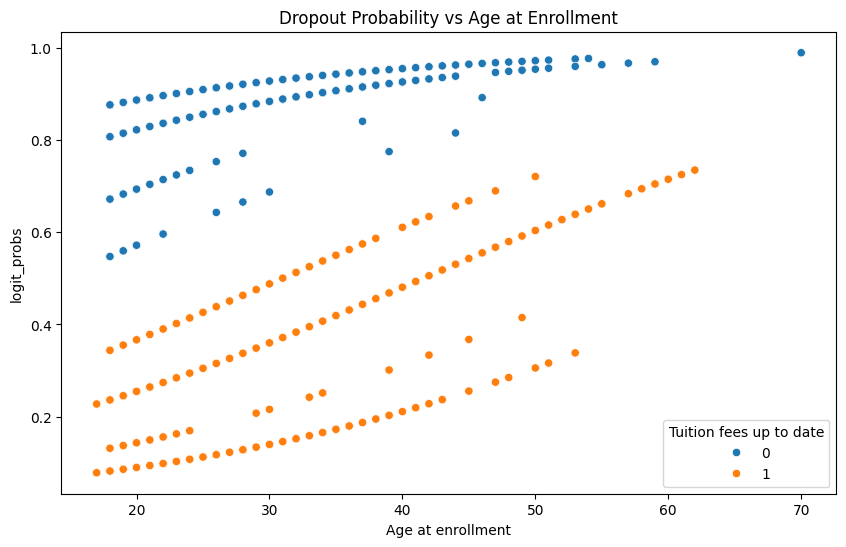

In [32]:
df['logit_probs'] = logit_reg.predict_proba(X)[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age at enrollment', y='logit_probs', hue='Tuition fees up to date')
plt.title('Dropout Probability vs Age at Enrollment')
plt.show()

For what ages does being up to date on tuition seem to reduce dropout probability the most? 

Being up to date on tuition reduces dropout probability the most for older students (ages 40 to 60). You can see this because the vertical gap between the blue dots (not up to date) and the orange dots (up to date) is largest in that age range. For younger students, the dropout rates are already lower but for older students, the blue dots are close to 1.0 while the orange dots are a lot lower, showing a big decrease in risk when tuition is up to date.

On average, by how much does being up to date on tuition change the predicted probability of dropout?

By looking at the graph: On average, being up to date on tuition reduces the predicted probability of dropout by approximately 40% to 60% (or 0.4 to 0.6 on the y-axis). Most blue clusters are centered around 0.8–0.9, while the majority of orange clusters are centered around 0.3–0.6.

Using code:

In [35]:
df.groupby('Tuition fees up to date')['logit_probs'].mean().diff()

Tuition fees up to date
0         NaN
1   -0.618101
Name: logit_probs, dtype: float64

On average, being up to date on tuition changes dropout probability by -0.6181

### Q2, 4

In [37]:
y_pred = logit_reg.predict(X)
conf_matrix = pd.crosstab(y_pred, y, rownames=['Predicted'], colnames=['Actual'])
acc = accuracy_score(y, y_pred)

print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nAccuracy: {acc:.4f}")

Confusion Matrix:
Actual        0    1
Predicted           
0          2841  891
1           162  530

Accuracy: 0.7620


What is the accuracy? 0.7620

### Q2, 5

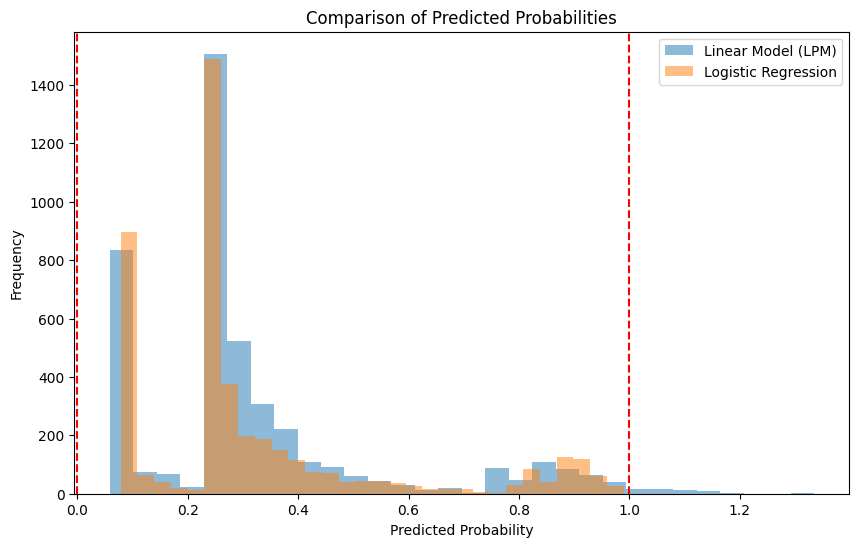

In [42]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
df['linear_probs'] = lin_reg.predict(X)

plt.figure(figsize=(10, 6))
plt.hist(df['linear_probs'], alpha=0.5, label='Linear Model (LPM)', bins=30)
plt.hist(df['logit_probs'], alpha=0.5, label='Logistic Regression', bins=30)
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Comparison of Predicted Probabilities')
plt.show()

The logistic regression model performs better because its predictions are always between 0 and 1 so they make sense as probabilities. In contrast, the linear probability model can give values greater than 1 or less than 0 which aren’t realistic. This happens because logistic regression uses a function that keeps predictions within a valid range, while the linear model doesn’t making its results harder to interpret.

### Q2, 6

Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

The students most at risk are older students who are behind on tuition and have outstanding debt, especially those without financial support like scholarships. To help them stay enrolled, the university could offer flexible payment plans, targeted scholarships for older or non-traditional students, and early financial support when students start falling behind on payments.

### Q2, 7

In [43]:
features = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X = df[features]
y = df['Target']

model = LogisticRegression(penalty=None, max_iter=5000)
model.fit(X, y)

/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [44]:
y_pred = model.predict(X)
conf_matrix = pd.crosstab(y, y_pred, rownames=['Actual'], colnames=['Predicted'])
accuracy = np.trace(conf_matrix) / len(y)

print("Confusion Matrix:")
print(conf_matrix)
print(f"\nOverall Accuracy: {accuracy:.4f}")

Confusion Matrix:
Predicted  Dropout  Graduate
Actual                      
Dropout       1054       367
Enrolled       280       514
Graduate       146      2063

Overall Accuracy: 0.3544


Describe your results. 

The multinomial logistic regression has an accuracy of about 35% which shows it doesn’t perform very well overall. From the confusion matrix, it does a decent job identifying Graduates and Dropouts, but it completely fails to predict any students as “Enrolled.” This suggests the model is mostly defaulting to the more obvious categories and struggling to distinguish students who are still enrolled.

In [45]:
probs = pd.DataFrame(model.predict_proba(X), columns=model.classes_)

print("Predicted Probabilities per Student")
print(probs.head())

print("\nAverage Probability for each class")
print(probs.mean())

Predicted Probabilities per Student
    Dropout  Enrolled  Graduate
0  0.680560  0.210486  0.108954
1  0.706615  0.145494  0.147892
2  0.954343  0.040341  0.005316
3  0.117346  0.176786  0.705867
4  0.183691  0.212551  0.603758

Average Probability for each class
Dropout     0.321232
Enrolled    0.179437
Graduate    0.499331
dtype: float64


Does your hard classification predict every class? Do your predicted probabilities predict every class?

Hard classification does not predict every class. In the confusion matrix, no students were predicted as “Enrolled” because it was never the highest probability for any student. “Dropout” or “Graduate” was always higher.

Predicted probabilities does predict every class. Each student still has some probability of being “Enrolled,” but since it’s never the largest value, it doesn’t show up in the final classification.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

### Q3, 1

In [21]:
cirr = pd.read_csv('/Users/clairicelou/Documents/DS3021/undergrad_ml_assignments/data/cirrhosis.csv')

cirr.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [22]:
cols_keep = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
cirr = cirr[cols_keep]

In [23]:
missing = cirr.isnull().sum()
print("Missing values per column:\n", missing)

Missing values per column:
 Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


Drug has 106 missing values and Stage has 6 missing values.

In [24]:
cirr = cirr.dropna()

### Q3, 2

In [48]:
cirr['is_dead'] = cirr['Status'].apply(lambda x: 1 if x == 'D' else 0)
y = cirr['is_dead']

In [49]:
X = pd.get_dummies(cirr[['Edema', 'Drug', 'Bilirubin']], drop_first=True)

In [50]:
logit_reg = LogisticRegression(penalty=None, max_iter=5000)
logit_reg.fit(X, y)

coeffs = pd.DataFrame({'Variable': X.columns, 'Coefficient': logit_reg.coef_[0]})
print(coeffs)

       Variable  Coefficient
0     Bilirubin     0.350381
1       Edema_S     0.578551
2       Edema_Y     2.859322
3  Drug_Placebo    -0.252657


/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

No the drug does not appear to improve survival in this model. The coefficient for Drug_Placebo is -0.253, which suggests that being in the placebo group actually has a slightly lower risk of death than being in the drug group.

Higher Billirubin levels predict a lower survival rate. The positive coefficient (0.35) means that as bilirubin increases, the probability of death increases.

Survival rate decreases as edema worsens. Compared to no edema, having resolvable edema (Edema_S) increases the risk of death (coefficient = 0.578), while severe edema (Edema_Y) increases it even more (coefficient = 2.859), meaning a much higher probability of death and a much lower survival rate.

### Q3, 3

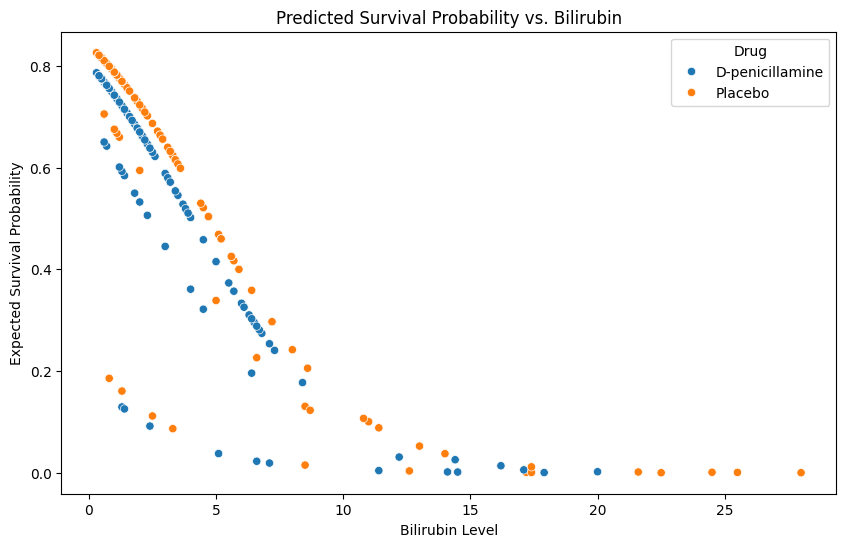

In [51]:
death_probs = logit_reg.predict_proba(X)[:, 1]
cirr['survival_prob'] = 1 - death_probs

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cirr, x='Bilirubin', y='survival_prob', hue='Drug')
plt.title('Predicted Survival Probability vs. Bilirubin')
plt.xlabel('Bilirubin Level')
plt.ylabel('Expected Survival Probability')
plt.show()

For what values of Bilirubin does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

From the graph, the drug (D-penicillamine) decrease survival probability across almost all bilirubin levels, since the blue dots are generally lower than the orange ones. This means there aren’t any bilirubin values where the drug clearly improves survival.

Using code:

In [52]:
cirr.groupby('Drug')['survival_prob'].mean()

Drug
D-penicillamine    0.588616
Placebo            0.610393
Name: survival_prob, dtype: float64

The survival probability for the drug group is 0.5886 and the placebo group is 0.6104.

Subtracting the 2 shows that patients who take the drug actually see a decrease in their average survival probability of approximately 2.18% or -0.0218 compared to those taking the placebo. So the drug does not increase survival it is associated with a slightly lower survival rate in this model.

### Q3, 4

In [53]:
y_pred = logit_reg.predict(X)
conf_matrix = pd.crosstab(y_pred, y, rownames=['Predicted'], colnames=['Actual'])
acc = accuracy_score(y, y_pred)

print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nAccuracy: {acc:.4f}")

Confusion Matrix:
Actual       0   1
Predicted         
0          173  68
1           14  57

Accuracy: 0.7372


The accuracy is 0.7372.

### Q3, 5

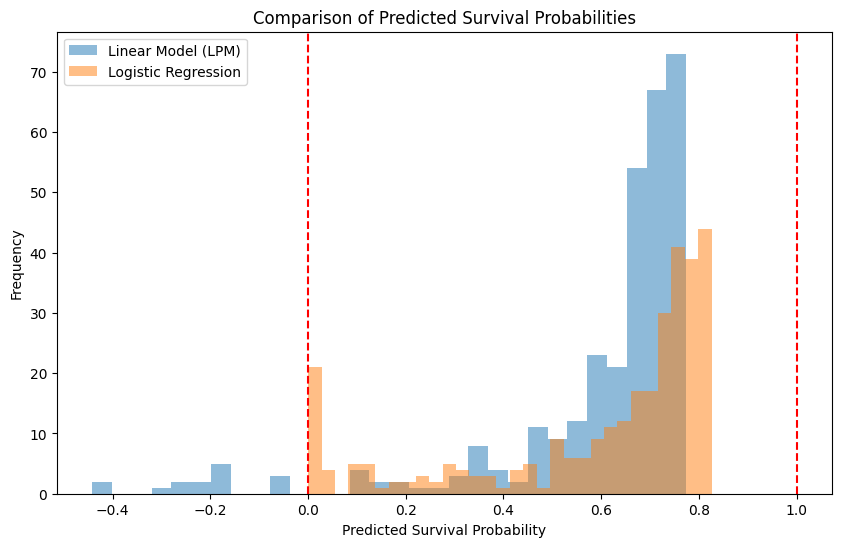

In [54]:
lin_reg = LinearRegression()
lin_reg.fit(X, y) 
cirr['linear_survival_prob'] = 1 - lin_reg.predict(X)

plt.figure(figsize=(10, 6))
plt.hist(cirr['linear_survival_prob'], alpha=0.5, label='Linear Model (LPM)', bins=30)
plt.hist(cirr['survival_prob'], alpha=0.5, label='Logistic Regression', bins=30)
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.xlabel('Predicted Survival Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Comparison of Predicted Survival Probabilities')
plt.show()

The logistic regression model works better than the linear model because it keeps all predictions between 0 and 1, which makes sense for probabilities. The linear model can give negative survival probabilities, which aren’t realistic or valid for this kind of problem.

### Q3, 6

In [55]:
X_stage = pd.get_dummies(cirr[['Edema', 'Bilirubin']], drop_first=True)
y_stage = cirr['Stage']

model_stage = LogisticRegression(penalty=None, max_iter=5000)
model_stage.fit(X_stage, y_stage)

/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [56]:
y_pred_stage = model_stage.predict(X_stage)
conf_matrix = pd.crosstab(y_stage, y_pred_stage, rownames=['Actual'], colnames=['Predicted'])
accuracy = np.trace(conf_matrix) / len(y_stage)

print("Confusion Matrix:")
print(conf_matrix)
print(f"\nOverall Accuracy: {accuracy:.4f}")

probs = pd.DataFrame(model_stage.predict_proba(X_stage), columns=model_stage.classes_)
print("\nAverage Probability for each Stage:")
print(probs.mean())

Confusion Matrix:
Predicted  3.0  4.0
Actual             
1.0         16    0
2.0         61    6
3.0        102   18
4.0         74   35

Overall Accuracy: 0.0705

Average Probability for each Stage:
1.0    0.051238
2.0    0.214676
3.0    0.384688
4.0    0.349398
dtype: float64


Describe your results.

The multinomial logistic regression had a very low accuracy (0.0705) because it didn’t predict any patients in Stage 1 or Stage 2. It gave higher probabilities for Stages 3 and 4, but the features in the model weren’t enough to clearly tell the four stages apart, so it mostly defaulted to the more severe ones.

In [58]:
probs = pd.DataFrame(model_stage.predict_proba(X_stage), columns=model_stage.classes_)

print("Predicted Probabilities per Patient:")
print(probs.head())

print("\nAverage Probability for each Stage:")
print(probs.mean())

Predicted Probabilities per Patient:
            1.0       2.0       3.0       4.0
0  2.964590e-08  0.022548  0.124086  0.853367
1  7.611337e-02  0.252747  0.397286  0.273854
2  2.404137e-07  0.175628  0.404099  0.420273
3  1.886844e-07  0.170140  0.403070  0.426790
4  2.053812e-02  0.228845  0.425473  0.325145

Average Probability for each Stage:
1.0    0.051238
2.0    0.214676
3.0    0.384688
4.0    0.349398
dtype: float64


Does your hard classification predict every class? Do your predicted probabilities predict every class?

No hard classification doesn’t predict every class. The confusion matrix only shows predictions for Stages 3 and 4 because, for every patient, one of those two stages always had the highest probability. Stages 1 and 2 were never “picked” as the final classification.

Yes the predicted probabilities predict every class. Even when a patient is classified as Stage 4, the model still assigns a small chance to Stage 1 or 2 (like how Stage 2 = 2.2%). On average, the model recognizes Stage 1 (5.1%) and Stage 2 (21.4%), even if those probabilities are rarely high enough to be the final prediction.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

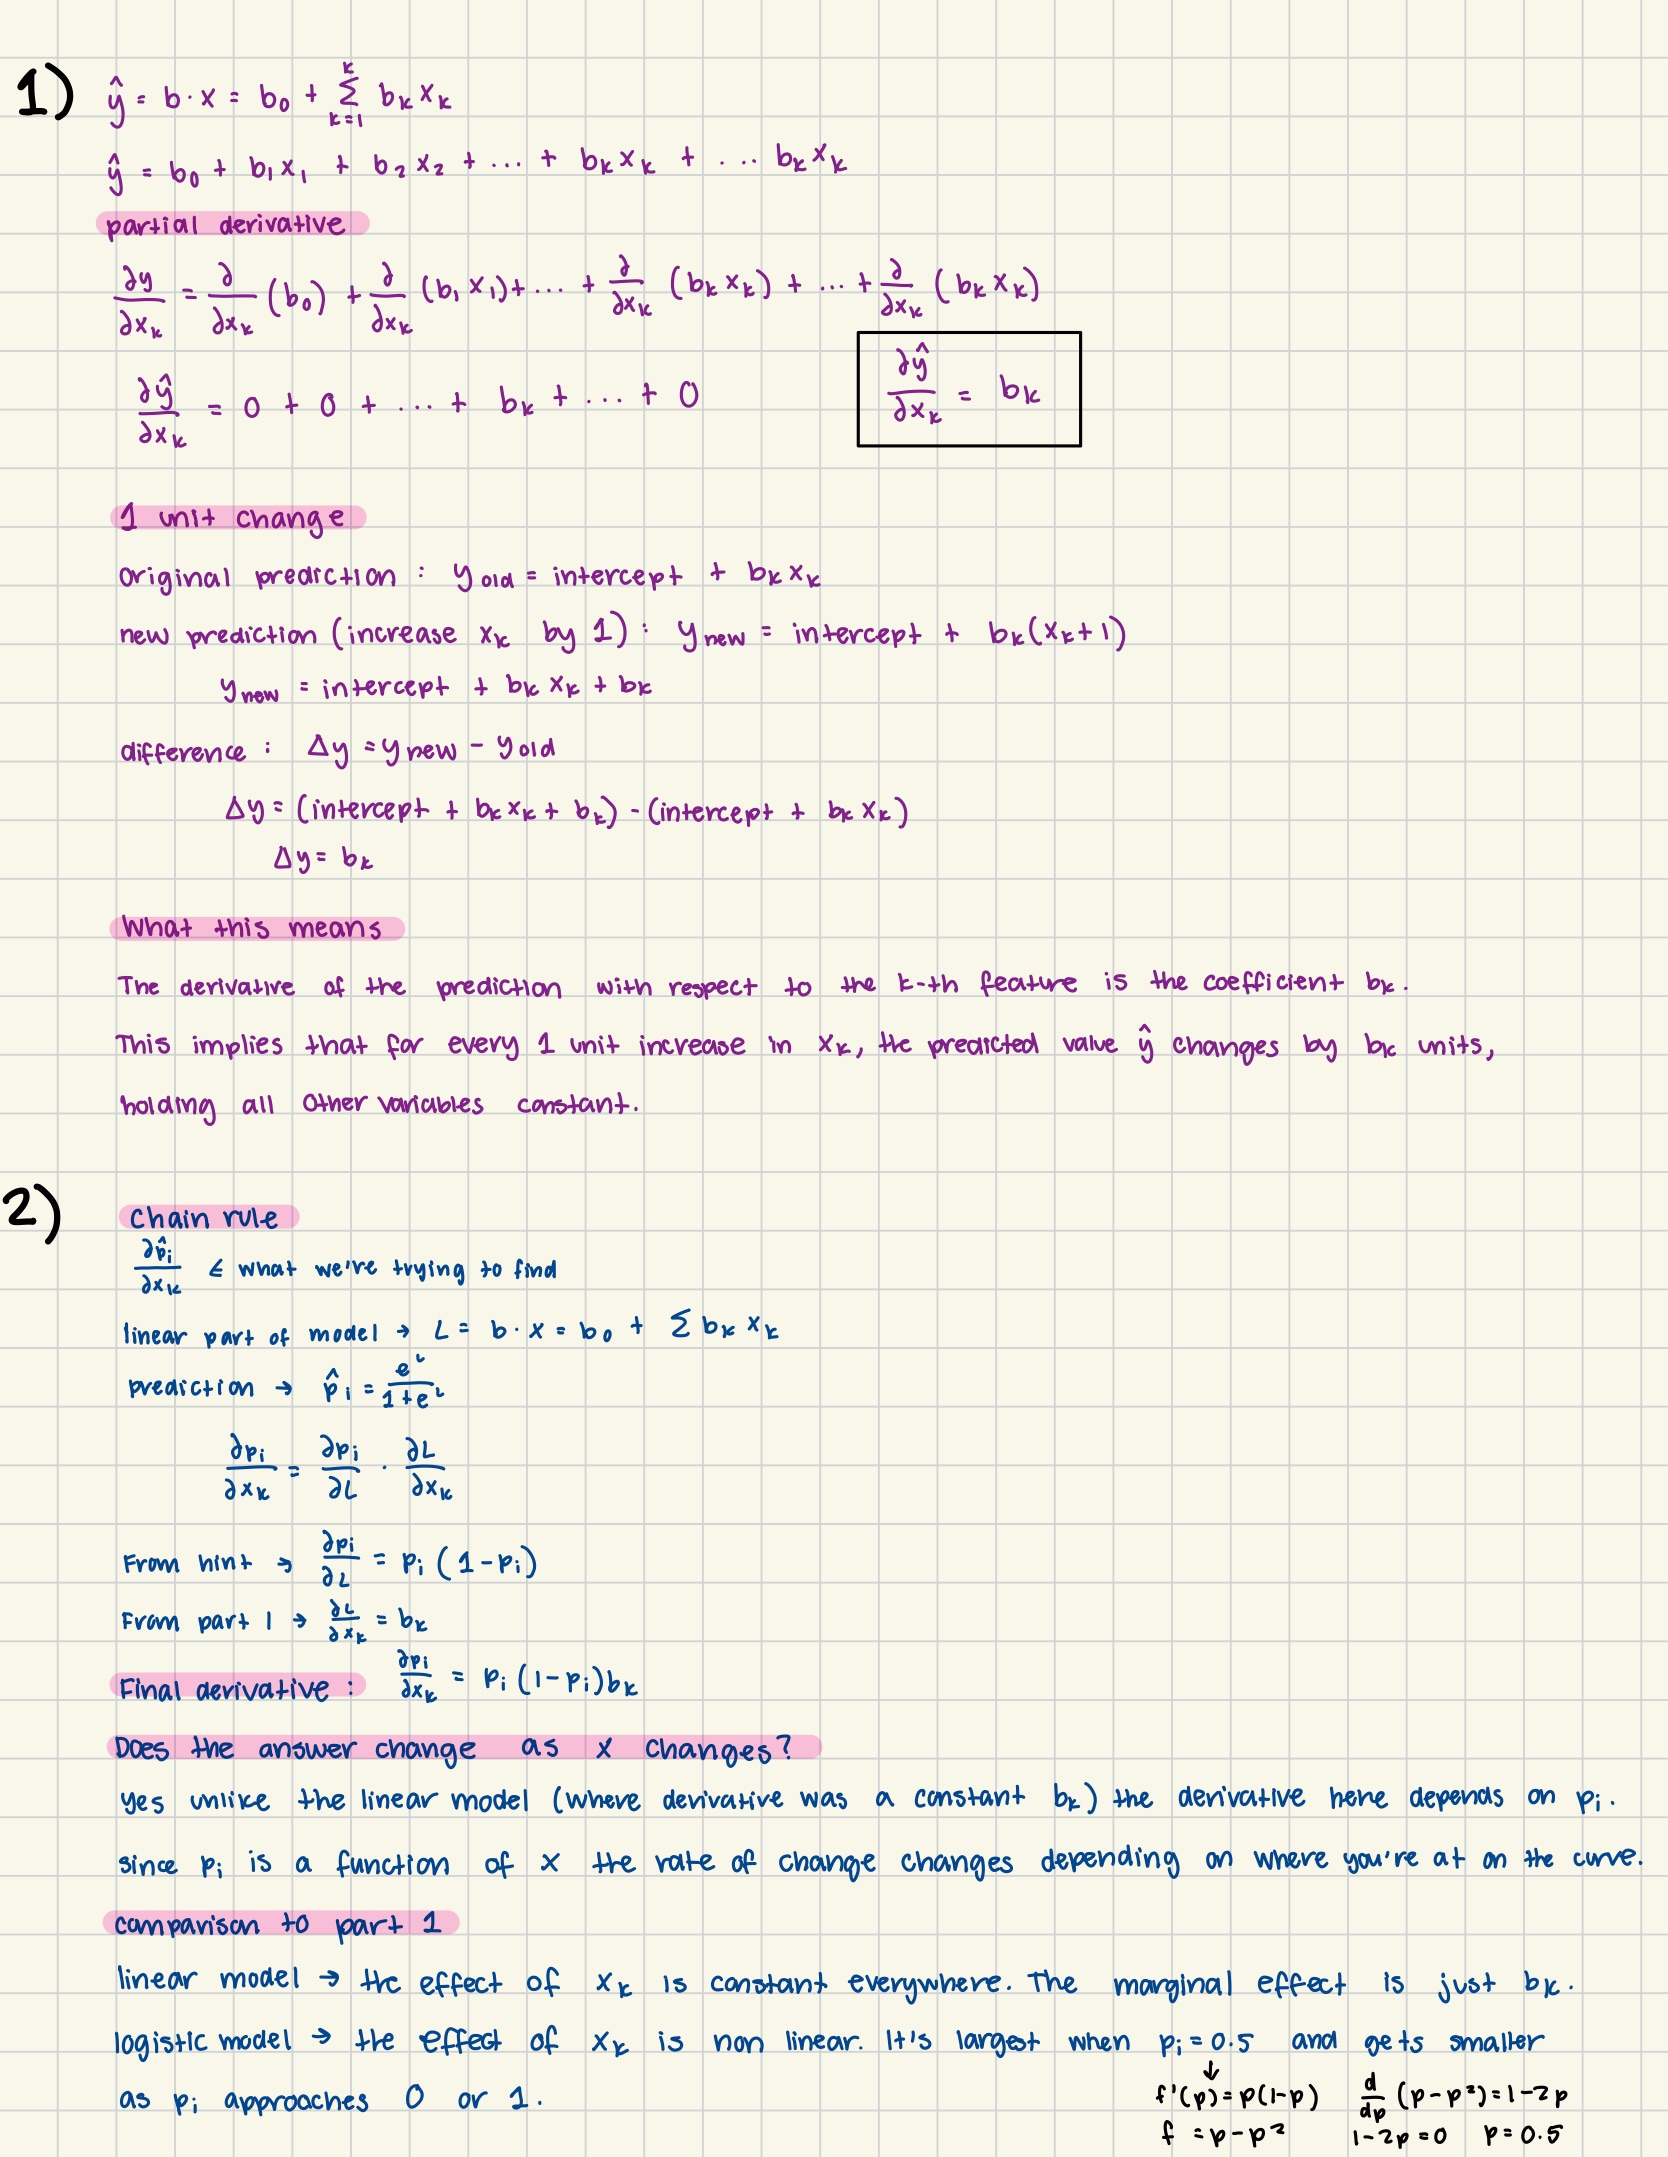

In [9]:
from IPython.display import Image
Image("Glmq4-1.png")

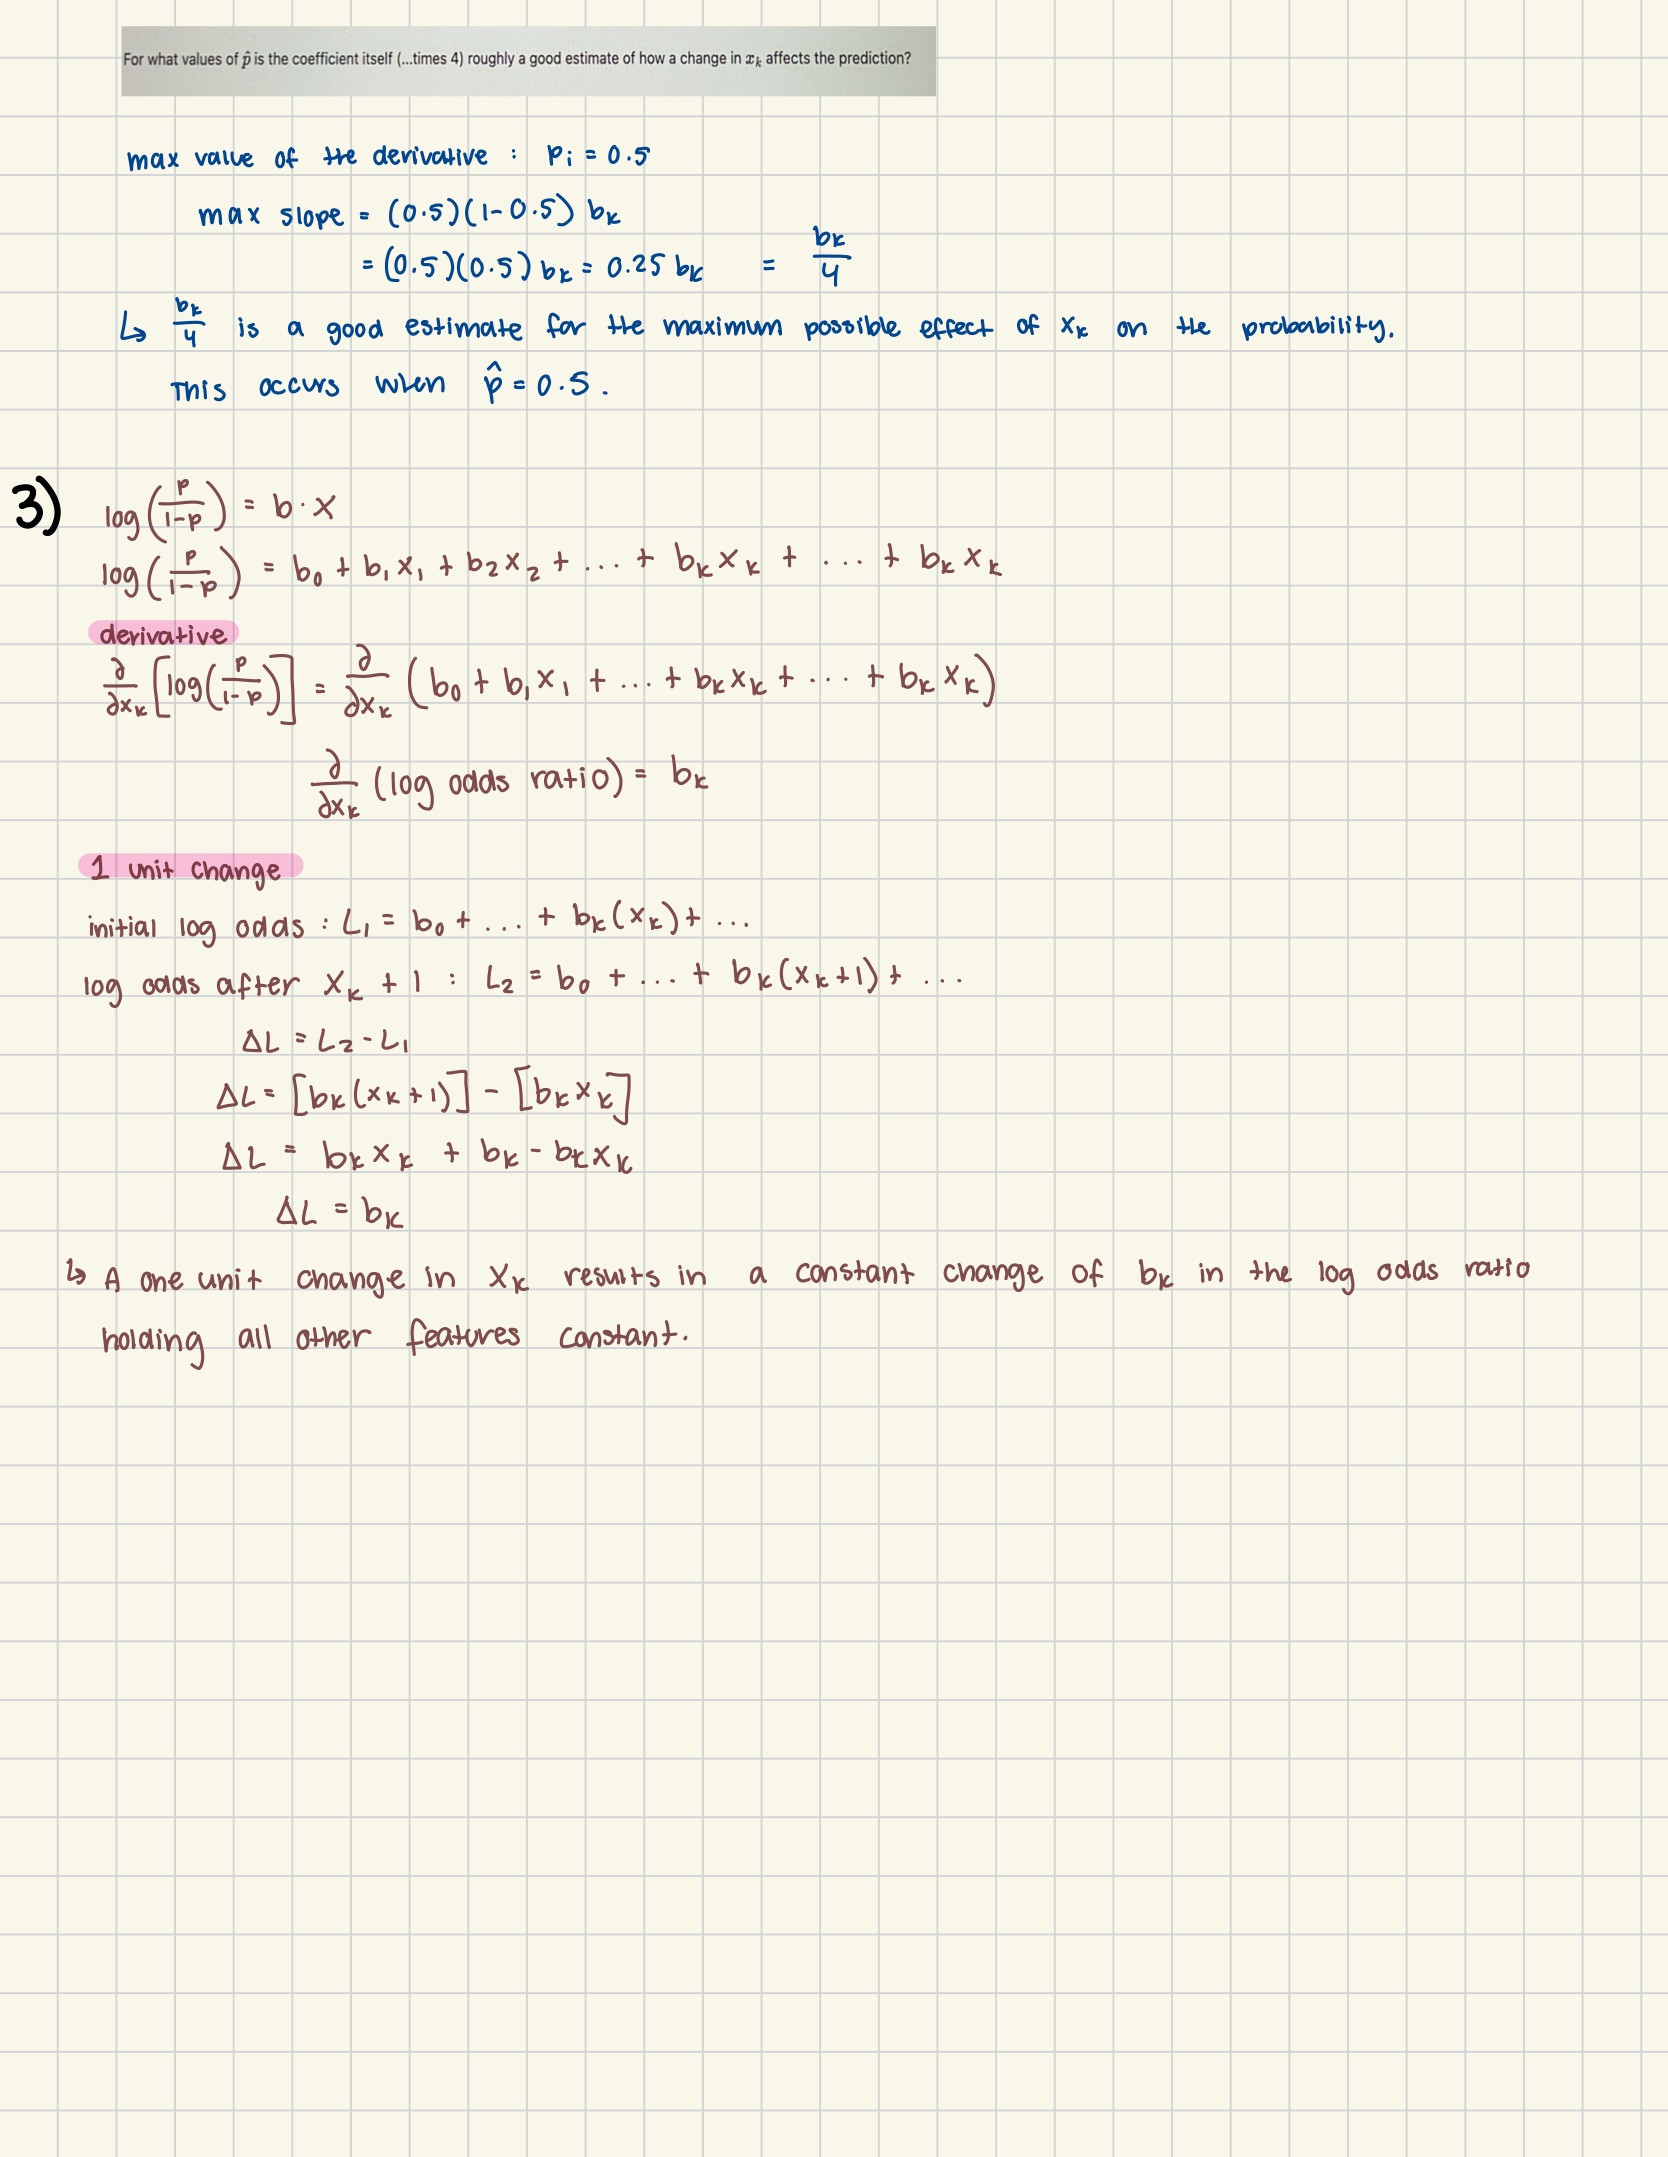

In [10]:
from IPython.display import Image
Image("Glmq4-2.png")